In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
decoded_variables= {'sound_category'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22,24]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA10-1L', '2023-03-31', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all = data_handler.process_multiple_datasets(datasets, model_type) 
#results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
#results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives each split!

# model_type = 'GLM_3nmf_passive'
# results_pass = data_handler.process_multiple_datasets(datasets, model_type)

Processing dataset: HA11-1R_2023-04-13
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
Processing dataset: HA2-1L_2023-04-28
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
decoder_results_regular_sound_category.mat
Processing dataset: HA1-00_2023-07-07
decoder_results_regular_s

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [ ]:
results_pre_all['HA11-1R_2023-04-13']['sound_category']['event_frame_mean']

array([71.])

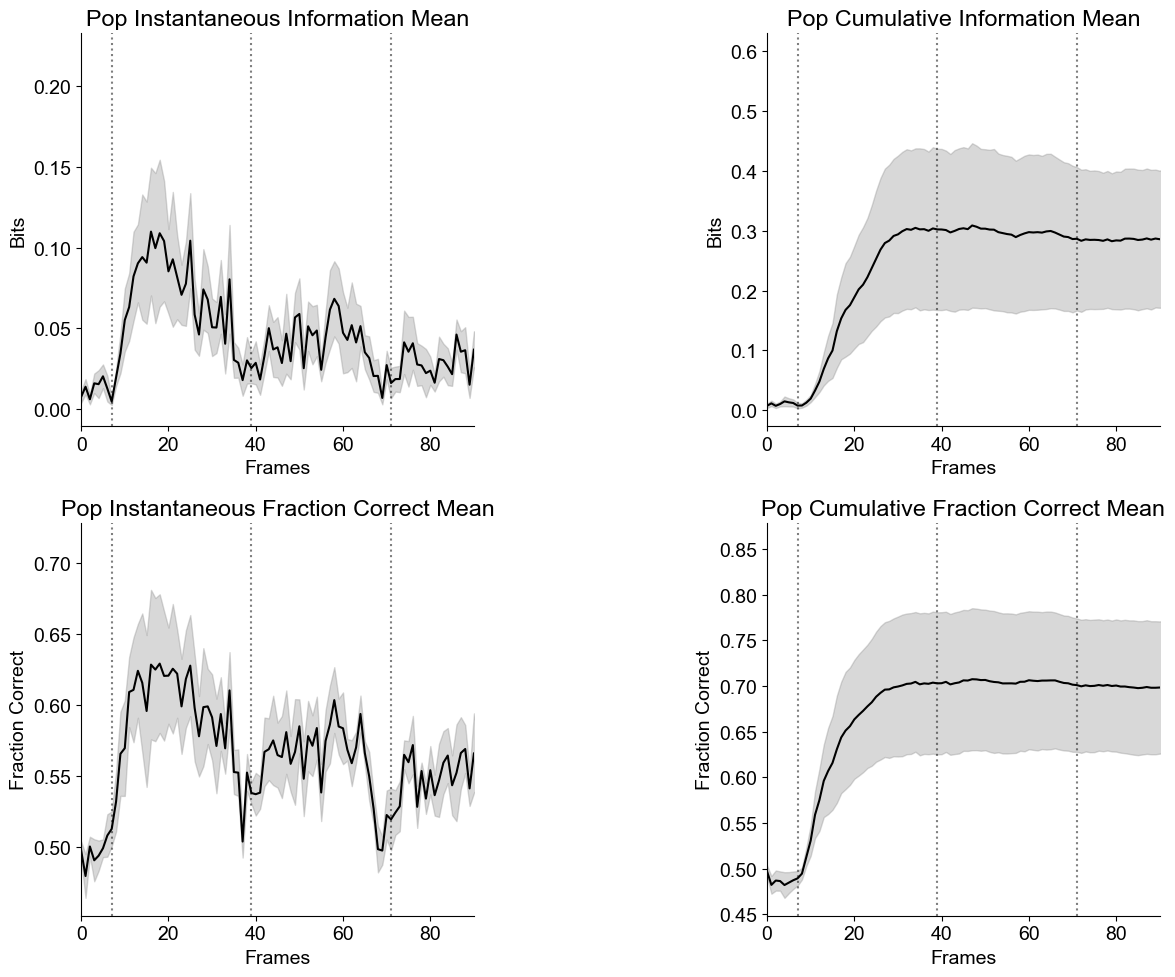

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_decoding_results(mean_results_all, decoder_type='choice', plot_type='pop', save_dir=None, xlim = None):
    """
    Plot mean decoding results across datasets.
    
    Args:
        mean_results_all (dict): Dictionary of mean results across datasets
        decoder_type (str): Type of decoding ('choice', 'sound_category', etc.)
        plot_type (str): 'pop' or 'sc' for population or single cell
        save_dir (str): Directory to save plots (optional)
    """
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    
    # Metrics to plot
    metrics = [
        f'{plot_type}_instantaneous_information_mean',
        f'{plot_type}_cumulative_information_mean',
        f'{plot_type}_instantaneous_fraction_correct_mean',
        f'{plot_type}_cumulative_fraction_correct_mean'
    ]

    # Get event frames from first dataset
    first_dataset = list(mean_results_all.keys())[0]
    event_frames = mean_results_all[first_dataset][decoder_type]['event_frame_mean']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flat
    
    for idx, metric in enumerate(metrics):
        # Collect data across datasets
        all_data = []
        for dataset in mean_results_all.keys():
            if decoder_type in mean_results_all[dataset]:
                data = mean_results_all[dataset][decoder_type][metric]
                all_data.append(data)
        
        # Calculate mean and SEM across datasets
        all_data = np.array(all_data)
        mean_trace = np.mean(all_data, axis=0)
        sem_trace = np.std(all_data, axis=0) / np.sqrt(len(all_data))
        
        # Plot
        ax = axes[idx]
        x = np.arange(len(mean_trace))
        ax.plot(mean_trace, 'k-', label='Mean')
        ax.fill_between(x, mean_trace-sem_trace, mean_trace+sem_trace, 
                       alpha=0.3, color='gray', label='SEM')
        
        # Add event markers
        for frame in event_frames:
            ax.axvline(x=frame, color='k', linestyle=':', alpha=0.5)
        
        # Formatting
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xlabel('Frames')
        if 'information' in metric:
            ax.set_ylabel('Bits')
        else:
            ax.set_ylabel('Fraction Correct')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_box_aspect(1)
        if xlim:
            ax.set_xlim(xlim)
        
    plt.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, f'{decoder_type}_{plot_type}_decoding.png'))
    
    plt.show()

# Usage example:
plot_decoding_results(results_pre_all, 
                     decoder_type='sound_category',
                     plot_type='pop',
                     save_dir=plotter.save_results,
                     xlim = (0,90)) 

In [8]:
# make plots of the mean decoding accuracy
plotter.plot_decoding_results(results_pre, mouse_dates_keys, 'sound_category', 'choice', 'photostim', 'outcome', 'shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome', save_results, 'pre')

AttributeError: 'Plotter' object has no attribute 'plot_decoding_results'